    Instructions:
    1. Run task_0a.py to generate the vector database if not already generated.
    2. Press Run All (or restart kernel and run all cells).
    3. You will be prompted to provide input values.


    – Task 1: Implement a program which, given (a) a query label, l (b) a user selected feature space, and (c) 
    positive integer k, identifies and visualizes the most relevant k images for the given label l, along with 
    their scores, under the selected feature space.

In [1]:
LABEL = input("Provide a label present in the Caltech101 dataset.")

FEATURE_SPACE = input("Provide a feature space [color, hog, avgpool, layer3, fc, resnet_output].")

K = int(input("Enter K, the number of similar images K to find for the selected feature space."))

In [2]:
# Find the k most similar images for a given query label for the given feature space.

from utils.query_input_processor import check_label_is_valid

check_label_is_valid(LABEL)

Input label:  airplanes 


Files already downloaded and verified


In [3]:
# Load feature space and representative label vectors for that feature space.

from utils.database_utils import retrieve

feature_vectors = retrieve(f'{FEATURE_SPACE}.pt')
rep_label_vectors = retrieve(f'rep_label_{FEATURE_SPACE}.pt')

Files already downloaded and verified

K = 10  most similar images by  hog  feature space using distance:  correlation
1. 	Image ID:  984 		Distance:  0.03751389602951827


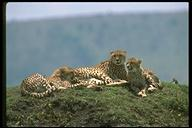

2. 	Image ID:  884 		Distance:  0.038392751260033275


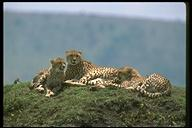

3. 	Image ID:  944 		Distance:  0.04469926719644279


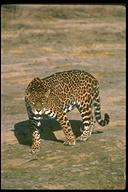

4. 	Image ID:  1044 		Distance:  0.045730613580136525


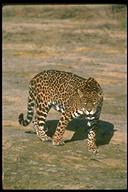

5. 	Image ID:  6990 		Distance:  0.048722567443439835


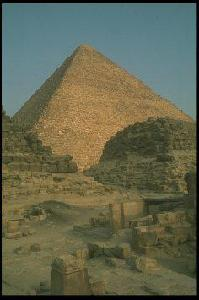

6. 	Image ID:  1000 		Distance:  0.048979408240811595


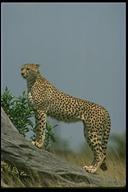

7. 	Image ID:  7406 		Distance:  0.049878734583445605


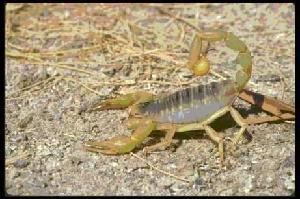

8. 	Image ID:  900 		Distance:  0.051857613201365726


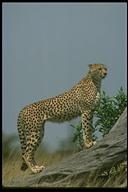

9. 	Image ID:  872 		Distance:  0.052409105237244735


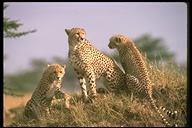

10. 	Image ID:  972 		Distance:  0.052526655279490186


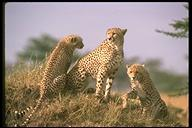

In [4]:
from utils.dataset_utils import initialize_dataset
dataset = initialize_dataset()

from utils.distance_utils import get_distance_fn, top_k_min_distance_ranker
top_k = top_k_min_distance_ranker(K, rep_label_vectors[LABEL], feature_vectors, get_distance_fn(FEATURE_SPACE))

print("\nK =", K, " most similar images by ", FEATURE_SPACE, " feature space using distance: ", get_distance_fn(FEATURE_SPACE).__name__)

for i in range(len(top_k)):

    distance, image_id, label = top_k[i]

    print(str(i + 1) + ".", "\tImage ID: ", image_id, "\t\tDistance: ", distance)
    display(dataset[image_id][0])